Bắt đầu huấn luyện LSTM trên thiết bị: cpu
Epoch [5/20] - Loss: 0.6114
Epoch [10/20] - Loss: 0.6110
Epoch [15/20] - Loss: 0.6109
Epoch [20/20] - Loss: 0.6098

Accuracy trên tập Test của LSTM: 74.46%
✅ Đã lưu trọng số mô hình PyTorch tại: ../models/lstm_gas.pth
BÁO CÁO PHÂN LOẠI MÔ HÌNH LSTM (TEST SET)
               precision    recall  f1-score   support

BEARISH (Bán)       0.74      1.00      0.85       312
BULLISH (Mua)       0.00      0.00      0.00       107

     accuracy                           0.74       419
    macro avg       0.37      0.50      0.43       419
 weighted avg       0.55      0.74      0.64       419

ROC-AUC Score: 0.5131


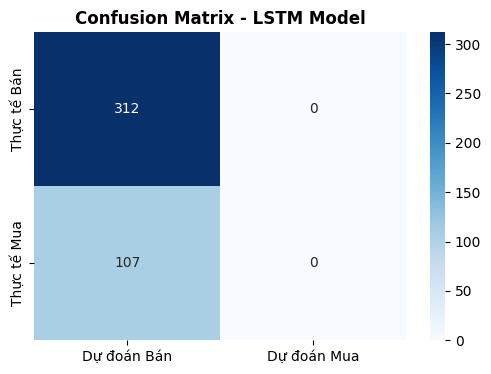


--- ĐANG CHẠY DỰ ĐOÁN REAL-TIME CHO MÃ GAS.VN ---


2026-07-31 12:03:53,772 [INFO] Bắt đầu tính toán Technical Indicators & Macro Features...
2026-07-31 12:03:54,363 [INFO] Hoàn tất. Tổng số features (bao gồm vĩ mô): 21
2026-07-31 12:03:54,363 [INFO] Đã loại bỏ 49 dòng NaN ở đầu chuỗi dữ liệu.


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 TÍN HIỆU DỰ ĐOÁN TỪ MÔ HÌNH LSTM - GAS.VN 
 Ngày cập nhật: 2026-07-31 | Giá đóng cửa: 68,700 VNĐ
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
>> KHUYẾN NGHỊ: BÁN / ĐỨNG NGOÀI (BEARISH) 🔴
>> Độ tự tin (Xác suất giảm): 68.93%
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


In [3]:
# Cell 1: Import thư viện và nạp dữ liệu
import sys
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import joblib

sys.path.append(os.path.abspath(".."))
from deep_learning.lstm_model import StockLSTM

# Nạp dữ liệu ML-ready đã chuẩn bị từ Notebook 06
df = pd.read_parquet("../data/processed/GAS_ml_ready.parquet")
feature_cols = [c for c in df.columns if c not in ['Target', 'Close']]

# Cell 2: Chuẩn hóa dữ liệu (Scaling) & Tạo 3D Sliding Window
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[feature_cols])

# Lưu Scaler lại để dùng khi Live Trading
os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/lstm_scaler.pkl")

# Hàm tạo cửa sổ trượt (Time Steps)
def create_sequences(data, targets, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(targets[i + seq_length])
    return np.array(X), np.array(y)

SEQ_LEN = 30  # Nhìn lại 30 ngày quá khứ
X_seq, y_seq = create_sequences(scaled_features, df['Target'].values, seq_length=SEQ_LEN)

# Chia Train/Test theo thời gian (80% Train, 20% Test)
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# Chuyển đổi sang PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=False)

# Cell 3: Vòng lặp Huấn luyện (Training Loop)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StockLSTM(input_size=len(feature_cols), hidden_size=64, num_layers=2).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 20
print(f"Bắt đầu huấn luyện LSTM trên thiết bị: {device}")

model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
                
        total_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {total_loss/len(train_loader):.4f}")

# Cell 4: Đánh giá và Lưu Model trọng số (.pth)
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t.to(device)).cpu().numpy()
    acc = ((test_preds > 0.5) == y_test_t.numpy()).mean()
    print(f"\nAccuracy trên tập Test của LSTM: {acc * 100:.2f}%")

# Sửa dòng cuối của Cell 4 thành:
torch.save(model.state_dict(), "../models/lstm_gas.pth")
print("✅ Đã lưu trọng số mô hình PyTorch tại: ../models/lstm_gas.pth")
# Cell 5: Đánh giá Chi tiết Mô hình (Classification Report & Confusion Matrix)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_binary = (test_preds > 0.5).astype(int)
y_true = y_test_t.numpy().astype(int)

print("=" * 60)
print("BÁO CÁO PHÂN LOẠI MÔ HÌNH LSTM (TEST SET)")
print("=" * 60)
print(classification_report(y_true, y_pred_binary, target_names=["BEARISH (Bán)", "BULLISH (Mua)"], zero_division=0))

auc_score = roc_auc_score(y_true, test_preds)
print(f"ROC-AUC Score: {auc_score:.4f}")

# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Dự đoán Bán", "Dự đoán Mua"],
            yticklabels=["Thực tế Bán", "Thực tế Mua"])
plt.title("Confusion Matrix - LSTM Model", fontsize=12, fontweight="bold")
plt.show()
# Cell 6: Dự đoán Tín hiệu Real-time cho Phiên Gần Nhất
import yfinance as yf

print("\n--- ĐANG CHẠY DỰ ĐOÁN REAL-TIME CHO MÃ GAS.VN ---")

# 1. Tải 60 phiên gần nhất từ Yahoo Finance để đảm bảo đủ 30 ngày sau khi dropna
df_live = yf.download("GAS.VN", period="100d", interval="1d", progress=False)

if isinstance(df_live.columns, pd.MultiIndex):
    df_live.columns = df_live.columns.get_level_values(0)

# 2. Tạo các tính năng kỹ thuật (Technical Features)
from utils.feature_engineer import TechnicalFeatures
te = TechnicalFeatures(df_live)
df_live_features = te.generate_all_features()

# 3. Lọc đúng các cột feature và loại bỏ NaN
df_live_clean = df_live_features[feature_cols].dropna()

# Lấy 30 phiên cuối cùng (30 time steps)
if len(df_live_clean) < SEQ_LEN:
    raise ValueError(f"Không đủ dữ liệu! Cần ít nhất {SEQ_LEN} phiên hợp lệ.")

last_30_days = df_live_clean.tail(SEQ_LEN)
latest_date = df_live.index[-1].strftime("%Y-%m-%d")
latest_close = float(df_live['Close'].iloc[-1])

# 4. Transform bằng Scaler đã lưu
scaled_live_30 = scaler.transform(last_30_days)

# 5. Chuyển sang dạng Tensor (1, 30, num_features)
X_live_tensor = torch.tensor(scaled_live_30, dtype=torch.float32).unsqueeze(0).to(device)

# 6. Dự đoán
model.eval()
with torch.no_grad():
    prob = model(X_live_tensor).item()
    pred_signal = 1 if prob > 0.5 else 0

# 7. Hiển thị báo cáo tín hiệu
print("★" * 50)
print(f" TÍN HIỆU DỰ ĐOÁN TỪ MÔ HÌNH LSTM - GAS.VN ")
print(f" Ngày cập nhật: {latest_date} | Giá đóng cửa: {latest_close:,.0f} VNĐ")
print("★" * 50)

if pred_signal == 1:
    print(">> KHUYẾN NGHỊ: MUA / NẮM GIỮ (BULLISH) 🟢")
    print(f">> Độ tự tin (Xác suất tăng): {prob * 100:.2f}%")
else:
    print(">> KHUYẾN NGHỊ: BÁN / ĐỨNG NGOÀI (BEARISH) 🔴")
    print(f">> Độ tự tin (Xác suất giảm): {(1 - prob) * 100:.2f}%")

print("★" * 50)
